# Airlines Delay Prediction using Deep Learning
### Models: ANN, LSTM, GRU, 1D-CNN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## ⚠️ Dataset Setup
Download the dataset from Kaggle:
https://www.kaggle.com/datasets/patrickzel/flight-delay-and-cancellation-dataset-2019-2023

Place `flights_sample_3m.csv` in the same directory as this notebook OR update the `dataset_path` variable below with your local path.

In [ ]:
# Update this path to where you downloaded the dataset locally
dataset_path = "flights_sample_3m.csv"  # place dataset in same folder or update path

df = pd.read_csv(dataset_path)
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (3000000, 32)

Columns: ['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE', 'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT']


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [4]:
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Stats:\n", df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA

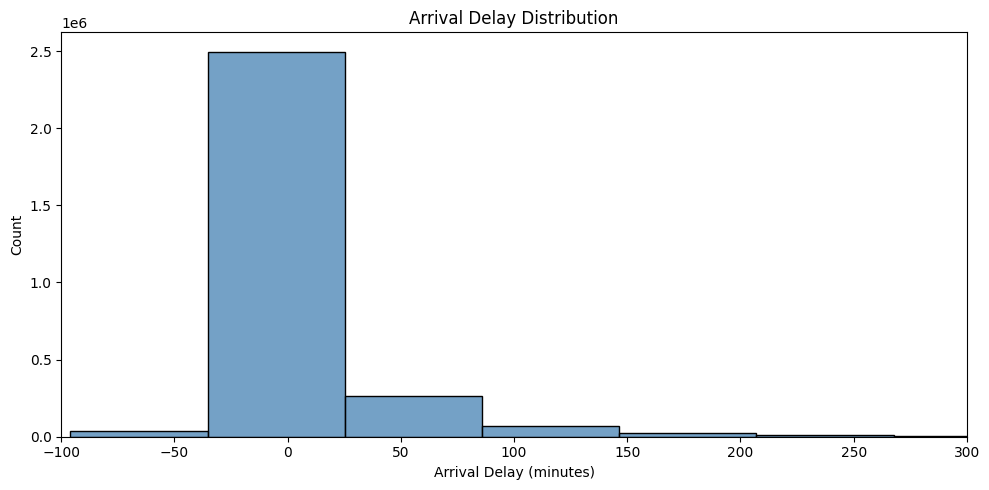

Plot saved!


In [5]:
plt.figure(figsize=(10,5))
sns.histplot(df['ARR_DELAY'].dropna(), bins=50, color='steelblue')
plt.title('Arrival Delay Distribution')
plt.xlabel('Arrival Delay (minutes)')
plt.ylabel('Count')
plt.xlim(-100, 300)
plt.tight_layout()
plt.savefig(r'../Images/arrival_delay_distribution.png')
plt.show()
print("Plot saved!")

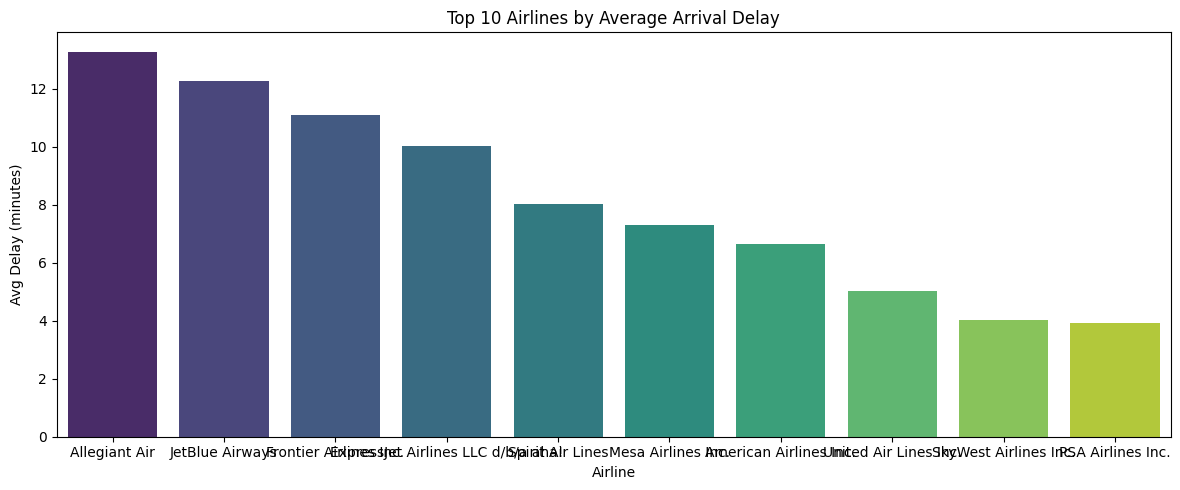

Plot saved!


In [6]:
avg_delay = df.groupby('AIRLINE')['ARR_DELAY'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,5))
sns.barplot(x=avg_delay.index, y=avg_delay.values, palette='viridis')
plt.title('Top 10 Airlines by Average Arrival Delay')
plt.xlabel('Airline')
plt.ylabel('Avg Delay (minutes)')
plt.tight_layout()
plt.savefig(r'../Images/top10_airlines_delay.png')
plt.show()
print("Plot saved!")

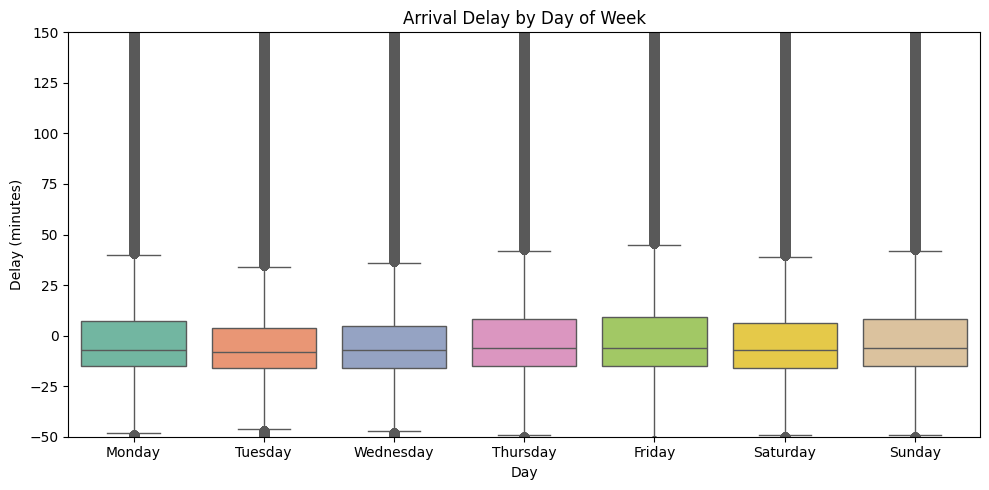

Plot saved!


In [7]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['DAY_OF_WEEK'] = df['FL_DATE'].dt.day_name()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='DAY_OF_WEEK', y='ARR_DELAY', order=day_order, palette='Set2')
plt.title('Arrival Delay by Day of Week')
plt.xlabel('Day')
plt.ylabel('Delay (minutes)')
plt.ylim(-50, 150)
plt.tight_layout()
plt.savefig(r'../Images/delay_by_day.png')
plt.show()
print("Plot saved!")

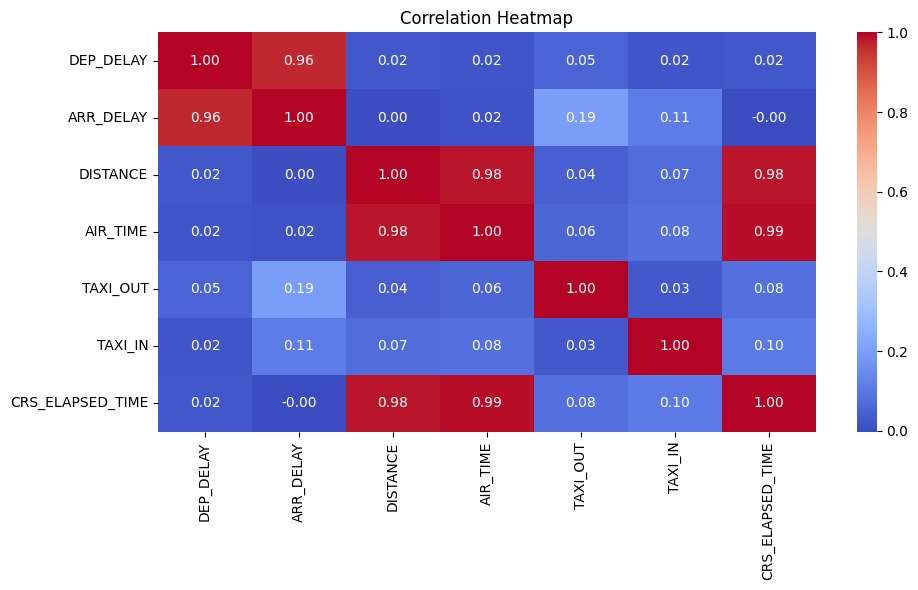

Plot saved!


In [8]:
cols = ['DEP_DELAY','ARR_DELAY','DISTANCE','AIR_TIME',
        'TAXI_OUT','TAXI_IN','CRS_ELAPSED_TIME']
plt.figure(figsize=(10,6))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(r'../Images/correlation_heatmap.png')
plt.show()
print("Plot saved!")

In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Use sample for faster training
df_model = df.sample(n=100000, random_state=42)

# Select features
features = ['DEP_DELAY','DISTANCE','AIR_TIME','TAXI_OUT',
            'TAXI_IN','CRS_ELAPSED_TIME','DAY_OF_WEEK']

target = 'ARR_DELAY'

# Encode DAY_OF_WEEK
le = LabelEncoder()
df_model['DAY_OF_WEEK'] = le.fit_transform(df_model['DAY_OF_WEEK'].astype(str))

# Drop nulls
df_model = df_model[features + [target]].dropna()

X = df_model[features].values
y = df_model[target].values

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(X)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (97164, 7)
y shape: (97164,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (77731, 7)
Test size: (19433, 7)


# ANN Model

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Build ANN
ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

ann_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
ann_history = ann_model.fit(X_train, y_train, 
                             epochs=20, batch_size=256,
                             validation_split=0.2, verbose=1)

# Evaluate
ann_pred = ann_model.predict(X_test).flatten()
ann_rmse = np.sqrt(mean_squared_error(y_test, ann_pred))
ann_mae = mean_absolute_error(y_test, ann_pred)
print(f"ANN → RMSE: {ann_rmse:.2f}, MAE: {ann_mae:.2f}")

Epoch 1/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 843.7803 - mae: 13.1178 - val_loss: 69.3533 - val_mae: 6.1344
Epoch 2/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 92.1339 - mae: 6.3392 - val_loss: 14.7766 - val_mae: 2.3787
Epoch 3/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 60.9312 - mae: 4.2298 - val_loss: 7.2730 - val_mae: 1.4004
Epoch 4/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 45.7736 - mae: 3.5479 - val_loss: 6.4369 - val_mae: 1.2726
Epoch 5/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 39.5573 - mae: 3.2143 - val_loss: 20.1403 - val_mae: 1.9421
Epoch 6/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 43.6450 - mae: 3.0321 - val_loss: 3.3006 - val_mae: 1.2456
Epoch 7/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 39.5223 - mae: 2.8544 - val_loss: 3.1020 - val_mae: 0.9607
Epoch 8/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 33.6076 - mae: 2.6499 - val_loss: 2.1452 - val_mae: 0.9676
Epoch 9/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 

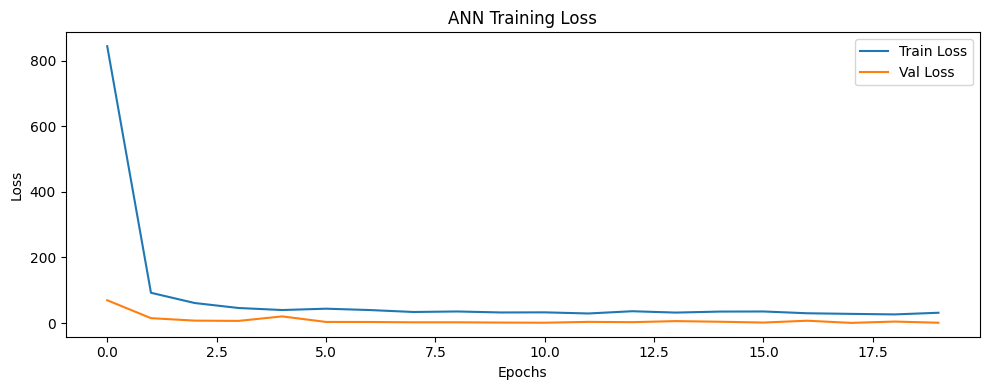

Plot saved!


In [12]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['loss'], label='Train Loss')
plt.plot(ann_history.history['val_loss'], label='Val Loss')
plt.title('ANN Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig(r'../Images/ann_loss.png')
plt.show()
print("Plot saved!")

# Reshape for LSTM/GRU/CNN

In [13]:
# Reshape for sequence models
X_train_seq = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_seq = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
print("Sequence shape:", X_train_seq.shape)

Sequence shape: (77731, 7, 1)


# LSTM

In [14]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train_seq.shape[1], 1)),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_history = lstm_model.fit(X_train_seq, y_train,
                               epochs=20, batch_size=256,
                               validation_split=0.2, verbose=1)

lstm_pred = lstm_model.predict(X_test_seq).flatten()
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_pred))
lstm_mae = mean_absolute_error(y_test, lstm_pred)
print(f"LSTM → RMSE: {lstm_rmse:.2f}, MAE: {lstm_mae:.2f}")

Epoch 1/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - loss: 2197.2227 - mae: 20.6315 - val_loss: 2555.6516 - val_mae: 19.1852
Epoch 2/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 1965.2533 - mae: 17.3134 - val_loss: 2345.7312 - val_mae: 16.7076
Epoch 3/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 1802.0437 - mae: 15.6032 - val_loss: 2182.3564 - val_mae: 14.7659
Epoch 4/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 1678.2753 - mae: 14.3207 - val_loss: 2074.9607 - val_mae: 13.9852
Epoch 5/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 1584.1060 - mae: 13.5965 - val_loss: 1988.1653 - val_mae: 13.5260
Epoch 6/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - loss: 1507.4855 - mae: 13.0447 - val_loss: 1908.9380 - val_mae: 13.0194
Epoch 7/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 1438.7357 - mae: 12.6088 - val_loss: 1837.2499 - val_mae: 12.5092
Epoch 8/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 1377.3064 - mae: 12.1956 - val_loss: 1773.7815

# GRU Model

In [15]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(X_train_seq.shape[1], 1)),
    Dropout(0.3),
    GRU(32),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
gru_history = gru_model.fit(X_train_seq, y_train,
                             epochs=20, batch_size=256,
                             validation_split=0.2, verbose=1)

gru_pred = gru_model.predict(X_test_seq).flatten()
gru_rmse = np.sqrt(mean_squared_error(y_test, gru_pred))
gru_mae = mean_absolute_error(y_test, gru_pred)
print(f"GRU → RMSE: {gru_rmse:.2f}, MAE: {gru_mae:.2f}")

Epoch 1/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - loss: 2190.7961 - mae: 20.0385 - val_loss: 2543.9873 - val_mae: 18.6268
Epoch 2/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 1943.0205 - mae: 16.4385 - val_loss: 2321.4739 - val_mae: 15.5765
Epoch 3/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 1786.4894 - mae: 14.7461 - val_loss: 2190.8726 - val_mae: 14.4962
Epoch 4/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 1678.2228 - mae: 13.8795 - val_loss: 2086.9331 - val_mae: 13.8233
Epoch 5/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 1587.7150 - mae: 13.1921 - val_loss: 1995.4343 - val_mae: 13.2010
Epoch 6/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 1509.1637 - mae: 12.6771 - val_loss: 1916.6123 - val_mae: 12.7539
Epoch 7/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 1438.4315 - mae: 12.1931 - val_loss: 1843.3967 - val_mae: 12.3179
Epoch 8/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 1376.3737 - mae: 11.8111 - val_loss: 1776.6510 

# 1D CNN Model

In [16]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

cnn_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', 
           input_shape=(X_train_seq.shape[1], 1), padding='same'),
    MaxPooling1D(pool_size=2, padding='same'),
    Conv1D(32, kernel_size=3, activation='relu', padding='same'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1)
])

cnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
cnn_history = cnn_model.fit(X_train_seq, y_train,
                             epochs=20, batch_size=256,
                             validation_split=0.2, verbose=1)

cnn_pred = cnn_model.predict(X_test_seq).flatten()
cnn_rmse = np.sqrt(mean_squared_error(y_test, cnn_pred))
cnn_mae = mean_absolute_error(y_test, cnn_pred)
print(f"1D-CNN → RMSE: {cnn_rmse:.2f}, MAE: {cnn_mae:.2f}")

Epoch 1/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 974.1356 - mae: 14.0519 - val_loss: 116.7987 - val_mae: 7.8513
Epoch 2/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 144.6339 - mae: 8.1050 - val_loss: 79.6718 - val_mae: 6.5726
Epoch 3/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 105.2933 - mae: 6.7230 - val_loss: 48.2290 - val_mae: 4.9668
Epoch 4/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 79.5597 - mae: 5.4937 - val_loss: 28.9304 - val_mae: 3.8104
Epoch 5/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 71.0130 - mae: 4.8004 - val_loss: 21.9816 - val_mae: 3.2389
Epoch 6/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 60.1291 - mae: 4.4196 - val_loss: 19.2039 - val_mae: 3.0010
Epoch 7/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 62.1134 - mae: 4.2489 - val_loss: 19.6739 - val_mae: 3.0795
Epoch 8/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 56.7872 - mae: 3.9736 - val_loss: 19.2091 - val_mae: 2.7357
Epoch 9/20
243/243 ━━━━━━━━━━━

## Final Comparison Table


=== Model Comparison ===
 Model      RMSE      MAE
   ANN  1.012656 0.608632
1D-CNN  2.513295 1.581910
   GRU 34.939252 3.943250
  LSTM 35.692967 8.518362


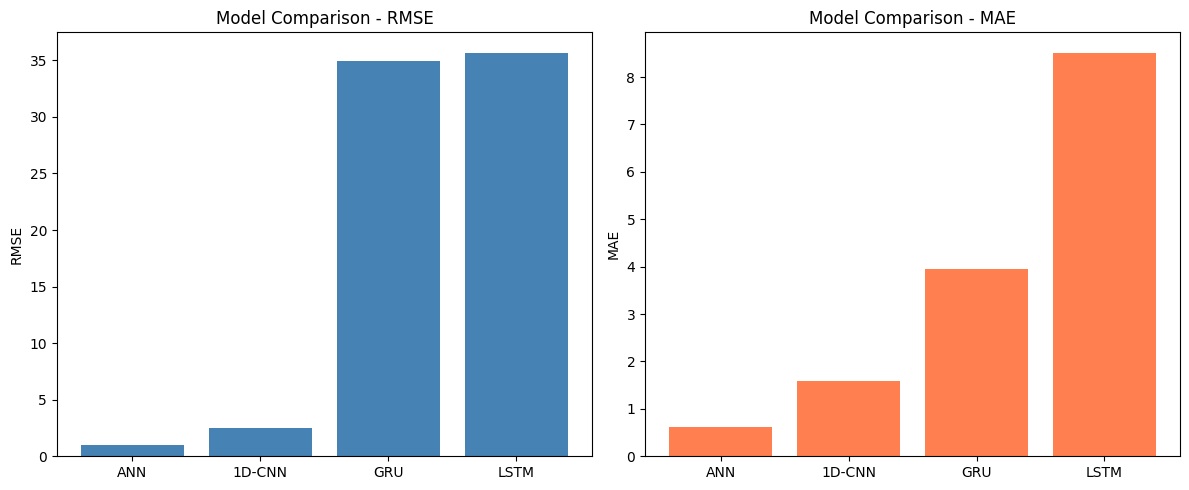

Plot saved!


In [17]:
results = {
    'Model': ['ANN', 'LSTM', 'GRU', '1D-CNN'],
    'RMSE': [ann_rmse, lstm_rmse, gru_rmse, cnn_rmse],
    'MAE': [ann_mae, lstm_mae, gru_mae, cnn_mae]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('RMSE')
print("\n=== Model Comparison ===")
print(results_df.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(results_df['Model'], results_df['RMSE'], color='steelblue')
axes[0].set_title('Model Comparison - RMSE')
axes[0].set_ylabel('RMSE')
axes[1].bar(results_df['Model'], results_df['MAE'], color='coral')
axes[1].set_title('Model Comparison - MAE')
axes[1].set_ylabel('MAE')
plt.tight_layout()
plt.savefig(r'../Images/model_comparison.png')
plt.show()
print("Plot saved!")